
# Reviewer 1 – Inactive-Compound Sampling Sensitivity Analysis
## Version 4: Pure Morgan-Fingerprint Matching

Bu notebook, tüm model uygulamalarında kullanılan GitHub `HIV7.csv` veri setini esas alır:

- **1,473 active**
- **1,412 inactive**
- **2,885 total**

Version 4'te alternatif inaktif training kümeleri, MoleculeNet HIV havuzundan yalnızca
**Morgan fingerprint–Tanimoto benzerliği** kullanılarak oluşturulur. Descriptor tabanlı
ön eleme yapılmaz.

Her orijinal HIV7 inaktifi için:

1. Uygun MoleculeNet inaktif havuzundaki tüm bileşiklerle Tanimoto benzerliği hesaplanır.
2. En benzer adaylar tutulur.
3. İlk adaylar içinde aynı Bemis–Murcko scaffold varsa bunlara öncelik verilir.
4. Adaylardan benzerlik ağırlıklı olasılıksal seçim yapılır.
5. Her alternatif bileşik yalnızca bir kez seçilir.

Bu analiz belirli bir sonucu elde etmek amacıyla değil, kimyasal olarak en doğrudan
eşleştirme yöntemiyle inactive-subset duyarlılığını değerlendirmek amacıyla tasarlanmıştır.


In [1]:

!pip -q install rdkit datasets pyarrow scipy scikit-learn tqdm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.4/37.4 MB 23.6 MB/s eta 0:00:00


## 1. Kütüphaneler ve deney ayarları

In [2]:

import json
import random
import warnings
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm
from scipy import stats

from rdkit import Chem, DataStructs, RDLogger
from rdkit.Chem import AllChem, Descriptors, Crippen, Lipinski, QED
from rdkit.Chem.Scaffolds import MurckoScaffold

from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix,
)

warnings.filterwarnings("ignore")
RDLogger.DisableLog("rdApp.*")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 220)
pd.set_option("display.float_format", lambda x: f"{x:.6f}")

GLOBAL_SEED = 45
N_REPETITIONS = 30
SAMPLING_SEEDS = list(range(N_REPETITIONS))

EXPECTED_ORIGINAL_ACTIVE = 1473
EXPECTED_ORIGINAL_INACTIVE = 1412
EXPECTED_ORIGINAL_TOTAL = 2885

TEST_ACTIVE_FRACTION = 0.20
N_INACTIVE_PER_TRAINING_SET = EXPECTED_ORIGINAL_INACTIVE

RADIUS = 2
N_BITS = 2048
DECISION_THRESHOLD = 0.50

# Her orijinal inaktif için saklanacak en yakın aday sayısı
TOP_K_NEIGHBORS = 50

# Her tekrarda seçim için ilk kaç kullanılabilir aday dikkate alınacak?
TOP_SELECTION_WINDOW = 20

# Yüksek Tanimoto değerlerini tercih eden olasılıksal seçim sıcaklığı
SIMILARITY_TEMPERATURE = 0.05

# İlk seçim penceresinde aynı scaffold varsa öncelik ver
PREFER_SAME_SCAFFOLD = True

RF_PARAMS = {
    "n_estimators": 100,
    "max_depth": None,
    "min_samples_split": 2,
    "min_samples_leaf": 1,
    "class_weight": None,
    "random_state": GLOBAL_SEED,
    "n_jobs": -1,
}

ORIGINAL_SUBSET_URL = (
    "https://raw.githubusercontent.com/McahitKutsal/hivcsv/main/HIV7.csv"
)
FULL_HIV_PRIMARY_URL = (
    "https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/HIV.csv"
)

OUTPUT_DIR = Path("reviewer1_inactive_sampling_v4_pure_fingerprint_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)

print("Sampling seeds:", SAMPLING_SEEDS)
print("Output directory:", OUTPUT_DIR.resolve())


Sampling seeds: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]
Output directory: /content/reviewer1_inactive_sampling_v4_pure_fingerprint_outputs


## 2. Yardımcı fonksiyonlar

In [3]:

def detect_column(df, candidates, role):
    lower_map = {str(c).strip().lower(): c for c in df.columns}
    for candidate in candidates:
        if str(candidate).lower() in lower_map:
            return lower_map[str(candidate).lower()]
    raise KeyError(f"{role} sütunu bulunamadı. Sütunlar: {list(df.columns)}")


def prepare_without_row_removal(df, dataset_name):
    smiles_col = detect_column(
        df,
        ["smiles", "SMILES", "Smiles", "smiles_sequence", "Smiles Sekansı"],
        "SMILES",
    )
    label_col = detect_column(
        df,
        ["HIV_active", "label", "labels", "y", "target", "activity_label"],
        "etiket",
    )

    out = pd.DataFrame({
        "source_row": np.arange(len(df), dtype=int),
        "smiles": df[smiles_col].astype(str).str.strip(),
        "label": pd.to_numeric(df[label_col], errors="coerce"),
    })

    invalid_label = ~out["label"].isin([0, 1])
    if invalid_label.any():
        raise ValueError(
            f"{dataset_name}: {invalid_label.sum()} ikili olmayan/eksik etiket var."
        )

    out["label"] = out["label"].astype(int)

    canonical, valid = [], []
    for smi in tqdm(out["smiles"], desc=f"{dataset_name}: SMILES doğrulama"):
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            canonical.append(None)
            valid.append(False)
        else:
            canonical.append(Chem.MolToSmiles(mol, canonical=True))
            valid.append(True)

    out["canonical_smiles"] = canonical
    out["valid_smiles"] = valid
    out["dataset_source"] = dataset_name

    report = {
        "dataset": dataset_name,
        "rows_preserved": int(len(out)),
        "active": int((out["label"] == 1).sum()),
        "inactive": int((out["label"] == 0).sum()),
        "invalid_smiles": int((~out["valid_smiles"]).sum()),
        "duplicate_raw_smiles_rows": int(out.duplicated("smiles").sum()),
        "duplicate_canonical_rows": int(
            out.loc[out["valid_smiles"]].duplicated("canonical_smiles").sum()
        ),
    }
    print(json.dumps(report, indent=2, ensure_ascii=False))
    return out, report


def load_full_moleculenet_hiv():
    errors = []
    try:
        df = pd.read_csv(FULL_HIV_PRIMARY_URL)
        return df, "DeepChem HIV.csv"
    except Exception as exc:
        errors.append(f"DeepChem CSV: {repr(exc)}")

    try:
        from datasets import load_dataset
        ds_obj = load_dataset("scikit-fingerprints/MoleculeNet_HIV")
        frames = []
        for split_name in ds_obj.keys():
            part = ds_obj[split_name].to_pandas()
            part["_hf_split"] = split_name
            frames.append(part)
        return pd.concat(frames, ignore_index=True), (
            "Hugging Face scikit-fingerprints/MoleculeNet_HIV"
        )
    except Exception as exc:
        errors.append(f"Hugging Face: {repr(exc)}")

    print("\n".join(errors))
    from google.colab import files
    uploaded = files.upload()
    if not uploaded:
        raise RuntimeError("MoleculeNet HIV dosyası yüklenmedi.")
    filename = next(iter(uploaded.keys()))
    if filename.lower().endswith(".parquet"):
        return pd.read_parquet(filename), f"manual:{filename}"
    return pd.read_csv(filename), f"manual:{filename}"


def scaffold_from_smiles(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None
    scaffold = MurckoScaffold.MurckoScaffoldSmiles(
        mol=mol, includeChirality=False
    )
    return scaffold if scaffold else "[NO_RING_SCAFFOLD]"


def descriptor_row(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return {
            "MW": np.nan, "LogP": np.nan, "TPSA": np.nan,
            "HBD": np.nan, "HBA": np.nan, "RotBonds": np.nan, "QED": np.nan
        }
    return {
        "MW": Descriptors.MolWt(mol),
        "LogP": Crippen.MolLogP(mol),
        "TPSA": Descriptors.TPSA(mol),
        "HBD": Lipinski.NumHDonors(mol),
        "HBA": Lipinski.NumHAcceptors(mol),
        "RotBonds": Lipinski.NumRotatableBonds(mol),
        "QED": QED.qed(mol),
    }


def add_chemical_features(df, desc="Chemical features"):
    out = df.copy().reset_index(drop=True)
    descriptors = pd.DataFrame([
        descriptor_row(smi)
        for smi in tqdm(out["smiles"], desc=desc)
    ])
    out = pd.concat([out, descriptors], axis=1)
    out["scaffold"] = [
        scaffold_from_smiles(smi)
        for smi in tqdm(out["smiles"], desc=f"{desc}: scaffolds")
    ]
    return out


def rdkit_fp_list(smiles_series, desc="Morgan fingerprints"):
    fps = []
    for smi in tqdm(smiles_series, desc=desc):
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            raise ValueError(f"Geçersiz SMILES: {smi}")
        fps.append(
            AllChem.GetMorganFingerprintAsBitVect(
                mol, radius=RADIUS, nBits=N_BITS
            )
        )
    return fps


def fingerprint_matrix(smiles_series, desc="Morgan matrix"):
    matrix = np.zeros((len(smiles_series), N_BITS), dtype=np.uint8)
    for i, smi in enumerate(tqdm(smiles_series, desc=desc)):
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            raise ValueError(f"Geçersiz SMILES: {smi}")
        fp = AllChem.GetMorganFingerprintAsBitVect(
            mol, radius=RADIUS, nBits=N_BITS
        )
        DataStructs.ConvertToNumpyArray(fp, matrix[i])
    return matrix


def calculate_metrics(y_true, y_prob, threshold=DECISION_THRESHOLD):
    y_true = np.asarray(y_true, dtype=int)
    y_prob = np.asarray(y_prob, dtype=float)
    y_pred = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true, y_pred, labels=[0, 1]
    ).ravel()
    specificity = tn / (tn + fp) if (tn + fp) else np.nan

    return {
        "roc_auc": float(roc_auc_score(y_true, y_prob)),
        "pr_auc": float(average_precision_score(y_true, y_prob)),
        "mcc": float(matthews_corrcoef(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "specificity": float(specificity),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "balanced_accuracy": float(
            balanced_accuracy_score(y_true, y_pred)
        ),
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
    }


def bootstrap_mean_ci(values, seed=GLOBAL_SEED, n_bootstrap=10000):
    values = np.asarray(values, dtype=float)
    rng = np.random.default_rng(seed)
    sampled = rng.choice(
        values, size=(n_bootstrap, len(values)), replace=True
    )
    low, high = np.percentile(sampled.mean(axis=1), [2.5, 97.5])
    return float(low), float(high)


def summarize_metric(values, metric_name):
    x = np.asarray(values, dtype=float)
    n = len(x)
    mean = float(np.mean(x))
    sd = float(np.std(x, ddof=1))
    median = float(np.median(x))
    q1, q3 = np.quantile(x, [0.25, 0.75])
    sem = stats.sem(x)
    tc = stats.t.ppf(0.975, df=n - 1)
    boot_low, boot_high = bootstrap_mean_ci(x)
    return {
        "metric": metric_name,
        "n": n,
        "mean": mean,
        "sd": sd,
        "median": median,
        "q1": float(q1),
        "q3": float(q3),
        "iqr": float(q3 - q1),
        "t_ci95_low": float(mean - tc * sem),
        "t_ci95_high": float(mean + tc * sem),
        "bootstrap_ci95_low": boot_low,
        "bootstrap_ci95_high": boot_high,
        "minimum": float(np.min(x)),
        "maximum": float(np.max(x)),
    }


def standardized_mean_difference(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    pooled = np.sqrt(
        ((len(x) - 1) * np.var(x, ddof=1) +
         (len(y) - 1) * np.var(y, ddof=1)) /
        (len(x) + len(y) - 2)
    )
    if pooled == 0:
        return 0.0
    return float((np.mean(y) - np.mean(x)) / pooled)


## 3. GitHub HIV7 veri setini doğrula

In [4]:

original_raw = pd.read_csv(ORIGINAL_SUBSET_URL)
original_df, original_report = prepare_without_row_removal(
    original_raw, "original_HIV7_subset"
)

observed_total = len(original_df)
observed_active = int((original_df["label"] == 1).sum())
observed_inactive = int((original_df["label"] == 0).sum())
observed_invalid = int((~original_df["valid_smiles"]).sum())

validation_table = pd.DataFrame([{
    "expected_total": EXPECTED_ORIGINAL_TOTAL,
    "observed_total": observed_total,
    "expected_active": EXPECTED_ORIGINAL_ACTIVE,
    "observed_active": observed_active,
    "expected_inactive": EXPECTED_ORIGINAL_INACTIVE,
    "observed_inactive": observed_inactive,
    "invalid_smiles": observed_invalid,
}])
display(validation_table)

assert observed_total == EXPECTED_ORIGINAL_TOTAL
assert observed_active == EXPECTED_ORIGINAL_ACTIVE
assert observed_inactive == EXPECTED_ORIGINAL_INACTIVE
assert observed_invalid == 0

validation_table.to_csv(
    OUTPUT_DIR / "original_HIV7_expected_vs_observed_v4.csv", index=False
)


original_HIV7_subset: SMILES doğrulama:   0%|          | 0/2885 [00:00<?, ?it/s]

{
  "dataset": "original_HIV7_subset",
  "rows_preserved": 2885,
  "active": 1473,
  "inactive": 1412,
  "invalid_smiles": 0,
  "duplicate_raw_smiles_rows": 30,
  "duplicate_canonical_rows": 30
}


,expected_total,observed_total,expected_active,observed_active,expected_inactive,observed_inactive,invalid_smiles
0,2885,2885,1473,1473,1412,1412,0


## 4. Tam MoleculeNet HIV veri setini yükle ve geçersiz SMILES kayıtlarını denetlenebilir biçimde çıkar

In [5]:

full_raw, full_source = load_full_moleculenet_hiv()
full_df, full_report = prepare_without_row_removal(
    full_raw, "full_MoleculeNet_HIV"
)

invalid_full = full_df[
    ~full_df["valid_smiles"]
].copy()

print("Geçersiz SMILES sayısı:", len(invalid_full))
if len(invalid_full) > 0:
    display(invalid_full[["source_row", "smiles", "label"]])
    invalid_full.to_csv(
        OUTPUT_DIR / "excluded_invalid_smiles_full_MoleculeNet_v4.csv",
        index=False,
    )

full_df_valid = full_df[
    full_df["valid_smiles"]
].copy().reset_index(drop=True)

original_active_all = original_df[
    original_df["label"] == 1
].copy().reset_index(drop=True)

original_inactive_all = original_df[
    original_df["label"] == 0
].copy().reset_index(drop=True)

full_inactive_all = full_df_valid[
    full_df_valid["label"] == 0
].copy().reset_index(drop=True)

print("\nTam veri kaynağı:", full_source)
print("Ham MoleculeNet toplam:", len(full_df))
print("Geçerli MoleculeNet toplam:", len(full_df_valid))
print("Hariç tutulan geçersiz SMILES:", len(invalid_full))
print("Geçerli full inactive:", len(full_inactive_all))

assert int((~full_df_valid["valid_smiles"]).sum()) == 0
assert len(full_df_valid) == len(full_df) - len(invalid_full)
assert len(full_inactive_all) > N_INACTIVE_PER_TRAINING_SET


full_MoleculeNet_HIV: SMILES doğrulama:   0%|          | 0/41127 [00:00<?, ?it/s]

{
  "dataset": "full_MoleculeNet_HIV",
  "rows_preserved": 41127,
  "active": 1443,
  "inactive": 39684,
  "invalid_smiles": 7,
  "duplicate_raw_smiles_rows": 0,
  "duplicate_canonical_rows": 0
}
Geçersiz SMILES sayısı: 7


,source_row,smiles,label
137,137,O=C1O[Al]23(OC1=O)(OC(=O)C(=O)O2)OC(=O)C(=O)O3,0
987,987,Cc1ccc([B-2]2(c3ccc(C)cc3)=NCCO2)cc1,0
12882,12882,Oc1ccc(C2Oc3cc(O)cc4c3C(=[O+][AlH3-3]35([O+]=C...,0
18293,18293,CC1=C2[OH+][AlH3-3]34([O+]=C2C=CN1C)([O+]=C1C=...,0
30784,30784,CC(c1cccs1)=[N+]1[N-]C(N)=[S+][AlH3-]12[OH+]B(...,0
30785,30785,CC(c1ccccn1)=[N+]1[N-]C(N)=[S+][AlH3-]12[OH+]B...,0
35728,35728,[Na+].c1ccc([SH+][GeH2+]2[SH+]c3ccccc3[SH+]2)c...,0



Tam veri kaynağı: DeepChem HIV.csv
Ham MoleculeNet toplam: 41127
Geçerli MoleculeNet toplam: 41120
Hariç tutulan geçersiz SMILES: 7
Geçerli full inactive: 39677


## 5. Canonical-SMILES grup temelli sabit training/test ayrımı

In [6]:

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=TEST_ACTIVE_FRACTION,
    random_state=GLOBAL_SEED,
)

train_idx, test_idx = next(
    splitter.split(
        original_active_all,
        y=original_active_all["label"],
        groups=original_active_all["canonical_smiles"],
    )
)

fixed_active_train = (
    original_active_all.iloc[train_idx].copy().reset_index(drop=True)
)
fixed_active_test = (
    original_active_all.iloc[test_idx].copy().reset_index(drop=True)
)

active_train_keys = set(fixed_active_train["canonical_smiles"])
active_test_keys = set(fixed_active_test["canonical_smiles"])
assert not (active_train_keys & active_test_keys)

n_test_inactive = len(fixed_active_test)
original_inactive_keys = set(original_inactive_all["canonical_smiles"])

forbidden_test_keys = (
    original_inactive_keys | active_train_keys | active_test_keys
)

external_inactive_candidates = full_inactive_all[
    ~full_inactive_all["canonical_smiles"].isin(forbidden_test_keys)
].drop_duplicates("canonical_smiles").reset_index(drop=True)

fixed_inactive_test = external_inactive_candidates.sample(
    n=n_test_inactive,
    replace=False,
    random_state=GLOBAL_SEED,
).reset_index(drop=True)

fixed_test_df = pd.concat(
    [fixed_active_test, fixed_inactive_test],
    ignore_index=True,
).sample(frac=1.0, random_state=GLOBAL_SEED).reset_index(drop=True)

test_keys = set(fixed_test_df["canonical_smiles"])

eligible_inactive_pool = full_inactive_all[
    ~full_inactive_all["canonical_smiles"].isin(
        test_keys | original_inactive_keys | active_train_keys
    )
].drop_duplicates("canonical_smiles").reset_index(drop=True)

original_baseline_train_df = pd.concat(
    [fixed_active_train, original_inactive_all],
    ignore_index=True,
).sample(frac=1.0, random_state=GLOBAL_SEED).reset_index(drop=True)

baseline_keys = set(original_baseline_train_df["canonical_smiles"])
assert not (baseline_keys & test_keys)
assert len(eligible_inactive_pool) >= N_INACTIVE_PER_TRAINING_SET

split_summary = pd.DataFrame([
    {
        "partition": "original_HIV7_raw",
        "active": int((original_df.label == 1).sum()),
        "inactive": int((original_df.label == 0).sum()),
        "total": len(original_df),
    },
    {
        "partition": "fixed_active_training",
        "active": len(fixed_active_train),
        "inactive": 0,
        "total": len(fixed_active_train),
    },
    {
        "partition": "fixed_held_out_test",
        "active": int((fixed_test_df.label == 1).sum()),
        "inactive": int((fixed_test_df.label == 0).sum()),
        "total": len(fixed_test_df),
    },
    {
        "partition": "original_baseline_training",
        "active": int((original_baseline_train_df.label == 1).sum()),
        "inactive": int((original_baseline_train_df.label == 0).sum()),
        "total": len(original_baseline_train_df),
    },
    {
        "partition": "eligible_fingerprint_matching_pool",
        "active": 0,
        "inactive": len(eligible_inactive_pool),
        "total": len(eligible_inactive_pool),
    },
])
display(split_summary)

split_summary.to_csv(OUTPUT_DIR / "split_summary_v4.csv", index=False)
fixed_test_df.to_csv(
    OUTPUT_DIR / "fixed_held_out_test_set_v4.csv", index=False
)
fixed_active_train.to_csv(
    OUTPUT_DIR / "fixed_active_training_set_v4.csv", index=False
)


,partition,active,inactive,total
0,original_HIV7_raw,1473,1412,2885
1,fixed_active_training,1175,0,1175
2,fixed_held_out_test,298,298,596
3,original_baseline_training,1175,1412,2587
4,eligible_fingerprint_matching_pool,0,37967,37967


## 6. Kimyasal özellikleri ve fingerprint'leri hesapla

In [7]:

original_inactive_features = add_chemical_features(
    original_inactive_all, "Original HIV7 inactive"
)
eligible_pool_features = add_chemical_features(
    eligible_inactive_pool, "Eligible inactive pool"
)

DESCRIPTOR_COLUMNS = [
    "MW", "LogP", "TPSA", "HBD", "HBA", "RotBonds", "QED"
]

original_fps = rdkit_fp_list(
    original_inactive_features["smiles"],
    "Original HIV7 Morgan fingerprints"
)
pool_fps = rdkit_fp_list(
    eligible_pool_features["smiles"],
    "Eligible pool Morgan fingerprints"
)

original_inactive_features.to_csv(
    OUTPUT_DIR / "original_inactive_chemical_features_v4.csv", index=False
)

print("Original fingerprints:", len(original_fps))
print("Pool fingerprints:", len(pool_fps))


Original HIV7 inactive:   0%|          | 0/1412 [00:00<?, ?it/s]

Original HIV7 inactive: scaffolds:   0%|          | 0/1412 [00:00<?, ?it/s]

Eligible inactive pool:   0%|          | 0/37967 [00:00<?, ?it/s]

Eligible inactive pool: scaffolds:   0%|          | 0/37967 [00:00<?, ?it/s]

Original HIV7 Morgan fingerprints:   0%|          | 0/1412 [00:00<?, ?it/s]

Eligible pool Morgan fingerprints:   0%|          | 0/37967 [00:00<?, ?it/s]

Original fingerprints: 1412
Pool fingerprints: 37967


## 7. Tüm havuzdan saf Tanimoto en-yakın-komşu listelerini oluştur

In [8]:

neighbor_rows = []
neighbor_lists = []

for original_idx, original_fp in enumerate(
    tqdm(original_fps, desc="All-pool Tanimoto nearest neighbors")
):
    similarities = np.asarray(
        DataStructs.BulkTanimotoSimilarity(original_fp, pool_fps),
        dtype=np.float32,
    )

    k = min(TOP_K_NEIGHBORS, len(similarities))
    top_idx_unsorted = np.argpartition(similarities, -k)[-k:]
    top_idx = top_idx_unsorted[
        np.argsort(similarities[top_idx_unsorted])[::-1]
    ]
    top_sims = similarities[top_idx]

    original_scaffold = original_inactive_features.loc[
        original_idx, "scaffold"
    ]
    same_scaffold = np.array([
        eligible_pool_features.loc[int(idx), "scaffold"] == original_scaffold
        for idx in top_idx
    ], dtype=bool)

    neighbor_lists.append({
        "pool_indices": top_idx.astype(int),
        "similarities": top_sims.astype(float),
        "same_scaffold": same_scaffold,
    })

    for rank, (pool_idx, sim, same) in enumerate(
        zip(top_idx, top_sims, same_scaffold), start=1
    ):
        neighbor_rows.append({
            "original_row": original_idx,
            "original_smiles": original_inactive_features.loc[
                original_idx, "smiles"
            ],
            "neighbor_rank": rank,
            "candidate_pool_index": int(pool_idx),
            "candidate_smiles": eligible_pool_features.loc[
                int(pool_idx), "smiles"
            ],
            "tanimoto_similarity": float(sim),
            "same_scaffold": bool(same),
        })

nearest_neighbor_audit = pd.DataFrame(neighbor_rows)
display(nearest_neighbor_audit.head(20))

nearest_neighbor_audit.to_csv(
    OUTPUT_DIR / "pure_tanimoto_nearest_neighbor_audit_v4.csv",
    index=False,
)

top1_summary = nearest_neighbor_audit[
    nearest_neighbor_audit["neighbor_rank"] == 1
]["tanimoto_similarity"].describe()

print("\nTop-1 similarity summary:")
display(top1_summary.to_frame("value"))


All-pool Tanimoto nearest neighbors:   0%|          | 0/1412 [00:00<?, ?it/s]

,original_row,original_smiles,neighbor_rank,candidate_pool_index,candidate_smiles,tanimoto_similarity,same_scaffold
0,0,CNC(=O)Nc1ccncc1,1,5852,CNC(=O)Nc1ccc(Cl)cn1,0.416667,True
1,0,CNC(=O)Nc1ccncc1,2,1478,O=C(NNC(=O)c1ccncc1)c1ccncc1,0.400000,False
2,0,CNC(=O)Nc1ccncc1,3,23796,CNC(=O)Nc1cc2c3c(c1)CCCN3CCC2,0.375000,False
3,0,CNC(=O)Nc1ccncc1,4,381,NNC(=O)c1ccncc1,0.375000,True
4,0,CNC(=O)Nc1ccncc1,5,15907,CSC(=S)NNC(=O)c1ccncc1,0.368421,True
5,0,CNC(=O)Nc1ccncc1,6,4044,O=C(NO)Nc1ccc(Cl)cc1,0.363636,False
6,0,CNC(=O)Nc1ccncc1,7,28533,O=C(Nc1ccc(C(F)(F)F)cc1)NC(F)(F)F,0.361111,False
7,0,CNC(=O)Nc1ccncc1,8,319,CC(=O)Nc1ccccc1,0.354839,False
8,0,CNC(=O)Nc1ccncc1,9,13736,O=C(NC(=O)c1ccccc1)Nc1ccccc1,0.342857,False
9,0,CNC(=O)Nc1ccncc1,10,6483,Cc1ccc(NC(=O)NC(=O)CCl)cc1,0.342105,False



Top-1 similarity summary:


,value
count,1412.000000
mean,0.543214
std,0.168708
min,0.150000
25%,0.411765
50%,0.533333
75%,0.657895
max,1.000000


## 8. Benzersiz, scaffold-tercihli fingerprint matching fonksiyonu

In [9]:

def sample_fingerprint_matched_inactives(seed):
    rng = np.random.default_rng(seed)
    used = set()
    selected_rows = []

    # En az güçlü eşleşmeye sahip orijinaller önce işlenir.
    # Böylece zor eşleşmelerin iyi adaylarının daha önce tüketilmesi önlenir.
    difficulty = np.array([
        info["similarities"][0] for info in neighbor_lists
    ])
    jitter = rng.uniform(0, 1e-8, size=len(difficulty))
    original_order = np.argsort(difficulty + jitter)

    for original_idx in original_order:
        info = neighbor_lists[original_idx]
        pool_idx = info["pool_indices"]
        sims = info["similarities"]
        same_scaffold = info["same_scaffold"]

        available_positions = [
            pos for pos, idx in enumerate(pool_idx)
            if int(idx) not in used
        ]

        if not available_positions:
            # Nadir fallback: tüm kullanılmamış havuzda yeniden saf Tanimoto taraması
            unused = np.array([
                idx for idx in range(len(pool_fps))
                if idx not in used
            ], dtype=int)
            if len(unused) == 0:
                raise RuntimeError("Eşleştirme havuzu tükendi.")

            fallback_sims = np.asarray(
                DataStructs.BulkTanimotoSimilarity(
                    original_fps[original_idx],
                    [pool_fps[int(j)] for j in unused],
                ),
                dtype=float,
            )
            best_pos = int(np.argmax(fallback_sims))
            chosen_pool_idx = int(unused[best_pos])
            chosen_sim = float(fallback_sims[best_pos])
            chosen_same_scaffold = bool(
                eligible_pool_features.loc[
                    chosen_pool_idx, "scaffold"
                ] == original_inactive_features.loc[
                    original_idx, "scaffold"
                ]
            )
            chosen_rank = np.nan
            fallback_used = True
        else:
            available_positions = available_positions[
                :TOP_SELECTION_WINDOW
            ]

            if PREFER_SAME_SCAFFOLD:
                same_scaffold_positions = [
                    pos for pos in available_positions
                    if same_scaffold[pos]
                ]
            else:
                same_scaffold_positions = []

            choice_positions = (
                same_scaffold_positions
                if same_scaffold_positions
                else available_positions
            )

            choice_sims = np.array(
                [sims[pos] for pos in choice_positions], dtype=float
            )
            logits = (
                choice_sims - np.max(choice_sims)
            ) / SIMILARITY_TEMPERATURE
            weights = np.exp(logits)
            weights = weights / weights.sum()

            selected_pos = int(
                rng.choice(choice_positions, p=weights)
            )

            chosen_pool_idx = int(pool_idx[selected_pos])
            chosen_sim = float(sims[selected_pos])
            chosen_same_scaffold = bool(
                same_scaffold[selected_pos]
            )
            chosen_rank = int(selected_pos + 1)
            fallback_used = False

        used.add(chosen_pool_idx)

        selected_rows.append({
            "sampling_seed": seed,
            "original_row": int(original_idx),
            "original_smiles": original_inactive_features.loc[
                original_idx, "smiles"
            ],
            "selected_pool_index": chosen_pool_idx,
            "selected_smiles": eligible_pool_features.loc[
                chosen_pool_idx, "smiles"
            ],
            "tanimoto_similarity": chosen_sim,
            "same_scaffold": chosen_same_scaffold,
            "candidate_rank": chosen_rank,
            "fallback_used": fallback_used,
        })

    match_table = pd.DataFrame(selected_rows).sort_values(
        "original_row"
    ).reset_index(drop=True)

    selected_df = eligible_pool_features.iloc[
        match_table["selected_pool_index"].to_numpy(dtype=int)
    ].copy().reset_index(drop=True)

    assert len(selected_df) == N_INACTIVE_PER_TRAINING_SET
    assert selected_df["canonical_smiles"].nunique() == len(selected_df)

    return selected_df, match_table


preview_selected, preview_matches = sample_fingerprint_matched_inactives(
    GLOBAL_SEED
)

print("Preview mean Tanimoto:",
      preview_matches["tanimoto_similarity"].mean())
print("Preview median Tanimoto:",
      preview_matches["tanimoto_similarity"].median())
print("Preview same-scaffold rate:",
      preview_matches["same_scaffold"].mean())
print("Preview fallback count:",
      preview_matches["fallback_used"].sum())
display(preview_matches.head())


Preview mean Tanimoto: 0.4874077973618217
Preview median Tanimoto: 0.47826087474823
Preview same-scaffold rate: 0.6303116147308782
Preview fallback count: 0


,sampling_seed,original_row,original_smiles,selected_pool_index,selected_smiles,tanimoto_similarity,same_scaffold,candidate_rank,fallback_used
0,45,0,CNC(=O)Nc1ccncc1,5852,CNC(=O)Nc1ccc(Cl)cn1,0.416667,True,1,False
1,45,1,O=C1NC(O)c2cccc(Cl)c2O1,6676,O=C1NC(O)c2ccccc2O1,0.555556,True,4,False
2,45,2,O=S1(=O)C=Cc2ccccc2CC1,18900,O=C1Cc2ccccc2CCc2ccccc21,0.270270,False,7,False
3,45,3,C=CCC(=S)NCCc1c[nH]c2ccccc12,19713,CCOC(=CC(=O)OC)NCCc1c[nH]c2ccccc12,0.482143,True,9,False
4,45,4,Oc1ccc(S)cc1CNC1CCCCC1,15150,O=C(NCCO)c1c(CNC2CCCCC2)[n+]([O-])c2ccccc2[n+]...,0.315789,False,5,False


## 9. Model fingerprint matrislerini hazırla

In [10]:

X_active_train = fingerprint_matrix(
    fixed_active_train["smiles"], "Active training matrix"
)
y_active_train = np.ones(len(fixed_active_train), dtype=int)

X_test = fingerprint_matrix(
    fixed_test_df["smiles"], "Fixed test matrix"
)
y_test = fixed_test_df["label"].to_numpy(dtype=int)

X_original_inactive = fingerprint_matrix(
    original_inactive_all["smiles"], "Original inactive matrix"
)
X_pool = fingerprint_matrix(
    eligible_pool_features["smiles"], "Eligible pool matrix"
)

print("X_active_train:", X_active_train.shape)
print("X_test:", X_test.shape)
print("X_original_inactive:", X_original_inactive.shape)
print("X_pool:", X_pool.shape)


Active training matrix:   0%|          | 0/1175 [00:00<?, ?it/s]

Fixed test matrix:   0%|          | 0/596 [00:00<?, ?it/s]

Original inactive matrix:   0%|          | 0/1412 [00:00<?, ?it/s]

Eligible pool matrix:   0%|          | 0/37967 [00:00<?, ?it/s]

X_active_train: (1175, 2048)
X_test: (596, 2048)
X_original_inactive: (1412, 2048)
X_pool: (37967, 2048)


## 10. Orijinal HIV7 baseline sonucu

In [11]:

X_baseline = np.vstack([X_active_train, X_original_inactive])
y_baseline = np.concatenate([
    y_active_train,
    np.zeros(len(X_original_inactive), dtype=int),
])

order = np.random.default_rng(GLOBAL_SEED).permutation(len(y_baseline))
X_baseline = X_baseline[order]
y_baseline = y_baseline[order]

baseline_model = RandomForestClassifier(**RF_PARAMS)
baseline_model.fit(X_baseline, y_baseline)

baseline_prob = baseline_model.predict_proba(X_test)[:, 1]
baseline_metrics = calculate_metrics(
    y_test, baseline_prob, DECISION_THRESHOLD
)

original_baseline_result = pd.DataFrame([{
    "strategy": "original_archived_1412_inactive_subset",
    **baseline_metrics,
    "n_train_active": int((y_baseline == 1).sum()),
    "n_train_inactive": int((y_baseline == 0).sum()),
    "n_test_active": int((y_test == 1).sum()),
    "n_test_inactive": int((y_test == 0).sum()),
}])

display(original_baseline_result)

original_baseline_result.to_csv(
    OUTPUT_DIR / "original_1412_inactive_baseline_metrics_v4.csv",
    index=False,
)


,strategy,roc_auc,pr_auc,mcc,precision,recall,specificity,f1,balanced_accuracy,tn,fp,fn,tp,n_train_active,n_train_inactive,n_test_active,n_test_inactive
0,original_archived_1412_inactive_subset,0.756210,0.812353,0.323381,0.648148,0.704698,0.617450,0.675241,0.661074,184,114,88,210,1175,1412,298,298


## 11. Ana analiz: 30 pure-fingerprint matched sampling tekrarı

In [12]:

results = []
all_matches = []
all_predictions = []

for run_number, seed in enumerate(SAMPLING_SEEDS, start=1):
    selected_df, match_table = sample_fingerprint_matched_inactives(seed)
    selected_indices = match_table[
        "selected_pool_index"
    ].to_numpy(dtype=int)

    X_selected = X_pool[selected_indices]

    X_train = np.vstack([X_active_train, X_selected])
    y_train = np.concatenate([
        y_active_train,
        np.zeros(len(X_selected), dtype=int),
    ])

    rng = np.random.default_rng(seed)
    train_order = rng.permutation(len(y_train))
    X_train = X_train[train_order]
    y_train = y_train[train_order]

    model = RandomForestClassifier(**RF_PARAMS)
    model.fit(X_train, y_train)

    probabilities = model.predict_proba(X_test)[:, 1]
    metrics = calculate_metrics(
        y_test, probabilities, DECISION_THRESHOLD
    )

    original_scaffolds = set(original_inactive_features["scaffold"])
    selected_scaffolds = set(selected_df["scaffold"])
    scaffold_union = len(original_scaffolds | selected_scaffolds)
    scaffold_jaccard = (
        len(original_scaffolds & selected_scaffolds) / scaffold_union
        if scaffold_union else np.nan
    )

    results.append({
        "sampling_seed": seed,
        **metrics,
        "mean_tanimoto_similarity": (
            match_table["tanimoto_similarity"].mean()
        ),
        "median_tanimoto_similarity": (
            match_table["tanimoto_similarity"].median()
        ),
        "q1_tanimoto_similarity": (
            match_table["tanimoto_similarity"].quantile(0.25)
        ),
        "q3_tanimoto_similarity": (
            match_table["tanimoto_similarity"].quantile(0.75)
        ),
        "minimum_tanimoto_similarity": (
            match_table["tanimoto_similarity"].min()
        ),
        "same_scaffold_rate": match_table["same_scaffold"].mean(),
        "fallback_count": int(match_table["fallback_used"].sum()),
        "unique_selected_scaffolds": selected_df["scaffold"].nunique(),
        "scaffold_jaccard_with_original": scaffold_jaccard,
        "n_train_active": int((y_train == 1).sum()),
        "n_train_inactive": int((y_train == 0).sum()),
        "n_test_active": int((y_test == 1).sum()),
        "n_test_inactive": int((y_test == 0).sum()),
    })

    match_table["sampling_seed"] = seed
    all_matches.append(match_table)

    for row_id, (smi, true_y, prob) in enumerate(zip(
        fixed_test_df["smiles"], y_test, probabilities
    )):
        all_predictions.append({
            "sampling_seed": seed,
            "test_row_id": row_id,
            "smiles": smi,
            "true_label": int(true_y),
            "predicted_probability": float(prob),
            "predicted_class": int(prob >= DECISION_THRESHOLD),
        })

    print(
        f"[{run_number:02d}/{N_REPETITIONS}] seed={seed:02d} | "
        f"ROC={metrics['roc_auc']:.4f} | "
        f"PR={metrics['pr_auc']:.4f} | "
        f"MCC={metrics['mcc']:.4f} | "
        f"Tanimoto={match_table['tanimoto_similarity'].mean():.3f} | "
        f"same scaffold={match_table['same_scaffold'].mean():.3f}"
    )

sampling_results = pd.DataFrame(results)
matched_records = pd.concat(all_matches, ignore_index=True)
prediction_results = pd.DataFrame(all_predictions)

display(sampling_results.head())

sampling_results.to_csv(
    OUTPUT_DIR / "pure_fingerprint_sampling_30_seeds_v4.csv",
    index=False,
)
matched_records.to_csv(
    OUTPUT_DIR / "matched_inactive_records_all_seeds_v4.csv",
    index=False,
)
prediction_results.to_csv(
    OUTPUT_DIR / "fixed_test_predictions_all_seeds_v4.csv",
    index=False,
)


[01/30] seed=00 | ROC=0.7764 | PR=0.8291 | MCC=0.4272 | Tanimoto=0.490 | same scaffold=0.630
[02/30] seed=01 | ROC=0.7624 | PR=0.8195 | MCC=0.4029 | Tanimoto=0.487 | same scaffold=0.633
[03/30] seed=02 | ROC=0.7774 | PR=0.8255 | MCC=0.4296 | Tanimoto=0.487 | same scaffold=0.632
[04/30] seed=03 | ROC=0.7620 | PR=0.8185 | MCC=0.3862 | Tanimoto=0.487 | same scaffold=0.631
[05/30] seed=04 | ROC=0.7632 | PR=0.8209 | MCC=0.3964 | Tanimoto=0.484 | same scaffold=0.633
[06/30] seed=05 | ROC=0.7763 | PR=0.8300 | MCC=0.4398 | Tanimoto=0.486 | same scaffold=0.632
[07/30] seed=06 | ROC=0.7715 | PR=0.8259 | MCC=0.3859 | Tanimoto=0.485 | same scaffold=0.630
[08/30] seed=07 | ROC=0.7661 | PR=0.8223 | MCC=0.4200 | Tanimoto=0.485 | same scaffold=0.631
[09/30] seed=08 | ROC=0.7583 | PR=0.8176 | MCC=0.3927 | Tanimoto=0.487 | same scaffold=0.632
[10/30] seed=09 | ROC=0.7794 | PR=0.8304 | MCC=0.4405 | Tanimoto=0.486 | same scaffold=0.628
[11/30] seed=10 | ROC=0.7682 | PR=0.8202 | MCC=0.4163 | Tanimoto=0.486

,sampling_seed,roc_auc,pr_auc,mcc,precision,recall,specificity,f1,balanced_accuracy,tn,fp,fn,tp,mean_tanimoto_similarity,median_tanimoto_similarity,q1_tanimoto_similarity,q3_tanimoto_similarity,minimum_tanimoto_similarity,same_scaffold_rate,fallback_count,unique_selected_scaffolds,scaffold_jaccard_with_original,n_train_active,n_train_inactive,n_test_active,n_test_inactive
0,0,0.776406,0.829081,0.427237,0.729242,0.677852,0.748322,0.702609,0.713087,223,75,96,202,0.489731,0.478261,0.350000,0.612903,0.105263,0.629603,0,815,0.310832,1175,1412,298,298
1,1,0.762449,0.819510,0.402911,0.708333,0.684564,0.718121,0.696246,0.701342,214,84,94,204,0.486571,0.475595,0.346939,0.612903,0.133333,0.633144,0,824,0.310695,1175,1412,298,298
2,2,0.777358,0.825493,0.429617,0.719178,0.704698,0.724832,0.711864,0.714765,216,82,88,210,0.487131,0.469988,0.347604,0.608961,0.117647,0.631728,0,811,0.316996,1175,1412,298,298
3,3,0.761981,0.818470,0.386169,0.700348,0.674497,0.711409,0.687179,0.692953,212,86,97,201,0.486526,0.469388,0.342105,0.615385,0.125000,0.631020,0,820,0.311668,1175,1412,298,298
4,4,0.763158,0.820933,0.396411,0.707746,0.674497,0.721477,0.690722,0.697987,215,83,97,201,0.483989,0.469388,0.341463,0.605263,0.111111,0.633144,0,820,0.310642,1175,1412,298,298


## 12. Metrik belirsizliği ve baseline karşılaştırması

In [13]:

required_metrics = ["roc_auc", "pr_auc", "mcc"]

uncertainty_summary = pd.DataFrame([
    summarize_metric(
        sampling_results[metric].to_numpy(),
        metric.upper(),
    )
    for metric in required_metrics
])

comparison_rows = []
for metric in required_metrics:
    values = sampling_results[metric].to_numpy()
    original_value = float(original_baseline_result.loc[0, metric])
    mean_value = float(values.mean())
    sd_value = float(values.std(ddof=1))

    comparison_rows.append({
        "metric": metric.upper(),
        "original_baseline": original_value,
        "fingerprint_matched_mean": mean_value,
        "fingerprint_matched_sd": sd_value,
        "original_minus_matched_mean": original_value - mean_value,
        "absolute_difference": abs(original_value - mean_value),
        "z_score": (
            (original_value - mean_value) / sd_value
            if sd_value > 0 else np.nan
        ),
        "empirical_percentile": float(
            100 * np.mean(values <= original_value)
        ),
        "inside_matched_min_max": bool(
            values.min() <= original_value <= values.max()
        ),
    })

original_vs_matched = pd.DataFrame(comparison_rows)

display(uncertainty_summary)
display(original_vs_matched)

uncertainty_summary.to_csv(
    OUTPUT_DIR / "fingerprint_sampling_uncertainty_summary_v4.csv",
    index=False,
)
original_vs_matched.to_csv(
    OUTPUT_DIR / "original_vs_fingerprint_matched_distribution_v4.csv",
    index=False,
)


,metric,n,mean,sd,median,q1,q3,iqr,t_ci95_low,t_ci95_high,bootstrap_ci95_low,bootstrap_ci95_high,minimum,maximum
0,ROC_AUC,30,0.768496,0.006019,0.769084,0.763243,0.772576,0.009334,0.766248,0.770743,0.766385,0.770568,0.756717,0.779436
1,PR_AUC,30,0.823627,0.003766,0.824200,0.820180,0.826511,0.006331,0.822221,0.825033,0.822289,0.824914,0.816808,0.830438
2,MCC,30,0.409151,0.015694,0.409788,0.402850,0.416617,0.013767,0.403291,0.415012,0.403556,0.414613,0.376254,0.440494


,metric,original_baseline,fingerprint_matched_mean,fingerprint_matched_sd,original_minus_matched_mean,absolute_difference,z_score,empirical_percentile,inside_matched_min_max
0,ROC_AUC,0.756210,0.768496,0.006019,-0.012285,0.012285,-2.041257,0.000000,False
1,PR_AUC,0.812353,0.823627,0.003766,-0.011274,0.011274,-2.993604,0.000000,False
2,MCC,0.323381,0.409151,0.015694,-0.085771,0.085771,-5.465026,0.000000,False


## 13. Tanimoto ve scaffold kalite özeti

In [14]:

tanimoto_quality_summary = pd.DataFrame([{
    "n_repetitions": N_REPETITIONS,
    "n_pairs_per_repetition": N_INACTIVE_PER_TRAINING_SET,
    "overall_mean_tanimoto": matched_records[
        "tanimoto_similarity"
    ].mean(),
    "overall_sd_tanimoto": matched_records[
        "tanimoto_similarity"
    ].std(ddof=1),
    "overall_median_tanimoto": matched_records[
        "tanimoto_similarity"
    ].median(),
    "overall_q1_tanimoto": matched_records[
        "tanimoto_similarity"
    ].quantile(0.25),
    "overall_q3_tanimoto": matched_records[
        "tanimoto_similarity"
    ].quantile(0.75),
    "overall_min_tanimoto": matched_records[
        "tanimoto_similarity"
    ].min(),
    "overall_max_tanimoto": matched_records[
        "tanimoto_similarity"
    ].max(),
    "mean_same_scaffold_rate": sampling_results[
        "same_scaffold_rate"
    ].mean(),
    "mean_scaffold_jaccard": sampling_results[
        "scaffold_jaccard_with_original"
    ].mean(),
    "total_fallback_count": matched_records[
        "fallback_used"
    ].sum(),
}])

display(tanimoto_quality_summary)

tanimoto_quality_summary.to_csv(
    OUTPUT_DIR / "tanimoto_scaffold_quality_summary_v4.csv",
    index=False,
)


,n_repetitions,n_pairs_per_repetition,overall_mean_tanimoto,overall_sd_tanimoto,overall_median_tanimoto,overall_q1_tanimoto,overall_q3_tanimoto,overall_min_tanimoto,overall_max_tanimoto,mean_same_scaffold_rate,mean_scaffold_jaccard,total_fallback_count
0,30,1412,0.485605,0.174571,0.472222,0.342105,0.609756,0.105263,1.000000,0.631398,0.309758,0


## 14. Descriptor denge analizi ve Standardized Mean Difference

In [15]:

descriptor_rows = []

for seed in SAMPLING_SEEDS:
    seed_matches = matched_records[
        matched_records["sampling_seed"] == seed
    ]
    selected = eligible_pool_features.iloc[
        seed_matches["selected_pool_index"].to_numpy(dtype=int)
    ]

    for descriptor in DESCRIPTOR_COLUMNS:
        original_values = original_inactive_features[
            descriptor
        ].to_numpy(dtype=float)
        selected_values = selected[
            descriptor
        ].to_numpy(dtype=float)

        descriptor_rows.append({
            "sampling_seed": seed,
            "descriptor": descriptor,
            "original_mean": float(np.mean(original_values)),
            "matched_mean": float(np.mean(selected_values)),
            "absolute_mean_difference": float(
                abs(np.mean(selected_values) - np.mean(original_values))
            ),
            "standardized_mean_difference": standardized_mean_difference(
                original_values, selected_values
            ),
            "absolute_smd": abs(standardized_mean_difference(
                original_values, selected_values
            )),
        })

descriptor_balance_all = pd.DataFrame(descriptor_rows)

descriptor_balance_summary = descriptor_balance_all.groupby(
    "descriptor", as_index=False
).agg(
    original_mean=("original_mean", "first"),
    matched_mean_across_seeds=("matched_mean", "mean"),
    matched_sd_across_seeds=("matched_mean", "std"),
    mean_absolute_difference=("absolute_mean_difference", "mean"),
    mean_smd=("standardized_mean_difference", "mean"),
    mean_absolute_smd=("absolute_smd", "mean"),
    maximum_absolute_smd=("absolute_smd", "max"),
)

display(descriptor_balance_summary)

descriptor_balance_all.to_csv(
    OUTPUT_DIR / "descriptor_balance_all_seeds_v4.csv",
    index=False,
)
descriptor_balance_summary.to_csv(
    OUTPUT_DIR / "descriptor_balance_summary_v4.csv",
    index=False,
)


,descriptor,original_mean,matched_mean_across_seeds,matched_sd_across_seeds,mean_absolute_difference,mean_smd,mean_absolute_smd,maximum_absolute_smd
0,HBA,3.250708,3.661756,0.027255,0.411048,0.257447,0.257447,0.284878
1,HBD,1.145892,1.220373,0.017803,0.074481,0.058983,0.058983,0.081822
2,LogP,1.648511,1.999104,0.029285,0.350593,0.195222,0.195222,0.224634
3,MW,218.065248,252.506561,1.269731,34.441313,0.520843,0.520843,0.566608
4,QED,0.598111,0.579267,0.002138,0.018845,-0.117909,0.117909,0.149978
5,RotBonds,2.395892,3.226582,0.047673,0.830689,0.263891,0.263891,0.286897
6,TPSA,52.330050,60.217689,0.491600,7.887639,0.251592,0.251592,0.285659


## 15. Makaleye hazır tablolar

In [16]:

table_rows = []

for metric in required_metrics:
    summary = uncertainty_summary[
        uncertainty_summary["metric"] == metric.upper()
    ].iloc[0]
    comp = original_vs_matched[
        original_vs_matched["metric"] == metric.upper()
    ].iloc[0]

    table_rows.append({
        "Metric": metric.upper(),
        "Original HIV7 subset": f"{comp['original_baseline']:.4f}",
        "Fingerprint-matched subsets, mean ± SD": (
            f"{summary['mean']:.4f} ± {summary['sd']:.4f}"
        ),
        "Bootstrap 95% CI": (
            f"{summary['bootstrap_ci95_low']:.4f}–"
            f"{summary['bootstrap_ci95_high']:.4f}"
        ),
        "Range": (
            f"{summary['minimum']:.4f}–{summary['maximum']:.4f}"
        ),
        "Absolute difference": f"{comp['absolute_difference']:.4f}",
        "Original inside matched range": comp["inside_matched_min_max"],
    })

manuscript_performance_table = pd.DataFrame(table_rows)
display(manuscript_performance_table)

chemical_matching_table = pd.DataFrame([{
    "Matching strategy": "Pure Morgan fingerprint–Tanimoto",
    "Number of repetitions": N_REPETITIONS,
    "Inactive compounds per repetition": N_INACTIVE_PER_TRAINING_SET,
    "Mean Tanimoto": (
        f"{tanimoto_quality_summary.loc[0, 'overall_mean_tanimoto']:.4f}"
    ),
    "Median Tanimoto": (
        f"{tanimoto_quality_summary.loc[0, 'overall_median_tanimoto']:.4f}"
    ),
    "Tanimoto IQR": (
        f"{tanimoto_quality_summary.loc[0, 'overall_q1_tanimoto']:.4f}–"
        f"{tanimoto_quality_summary.loc[0, 'overall_q3_tanimoto']:.4f}"
    ),
    "Mean same-scaffold rate": (
        f"{tanimoto_quality_summary.loc[0, 'mean_same_scaffold_rate']:.4f}"
    ),
    "Mean scaffold Jaccard": (
        f"{tanimoto_quality_summary.loc[0, 'mean_scaffold_jaccard']:.4f}"
    ),
}])

display(chemical_matching_table)

manuscript_performance_table.to_csv(
    OUTPUT_DIR / "manuscript_ready_performance_table_v4.csv",
    index=False,
)
chemical_matching_table.to_csv(
    OUTPUT_DIR / "manuscript_ready_matching_quality_table_v4.csv",
    index=False,
)


,Metric,Original HIV7 subset,"Fingerprint-matched subsets, mean ± SD",Bootstrap 95% CI,Range,Absolute difference,Original inside matched range
0,ROC_AUC,0.7562,0.7685 ± 0.0060,0.7664–0.7706,0.7567–0.7794,0.0123,False
1,PR_AUC,0.8124,0.8236 ± 0.0038,0.8223–0.8249,0.8168–0.8304,0.0113,False
2,MCC,0.3234,0.4092 ± 0.0157,0.4036–0.4146,0.3763–0.4405,0.0858,False


,Matching strategy,Number of repetitions,Inactive compounds per repetition,Mean Tanimoto,Median Tanimoto,Tanimoto IQR,Mean same-scaffold rate,Mean scaffold Jaccard
0,Pure Morgan fingerprint–Tanimoto,30,1412,0.4856,0.4722,0.3421–0.6098,0.6314,0.3098


## 16. Figürler

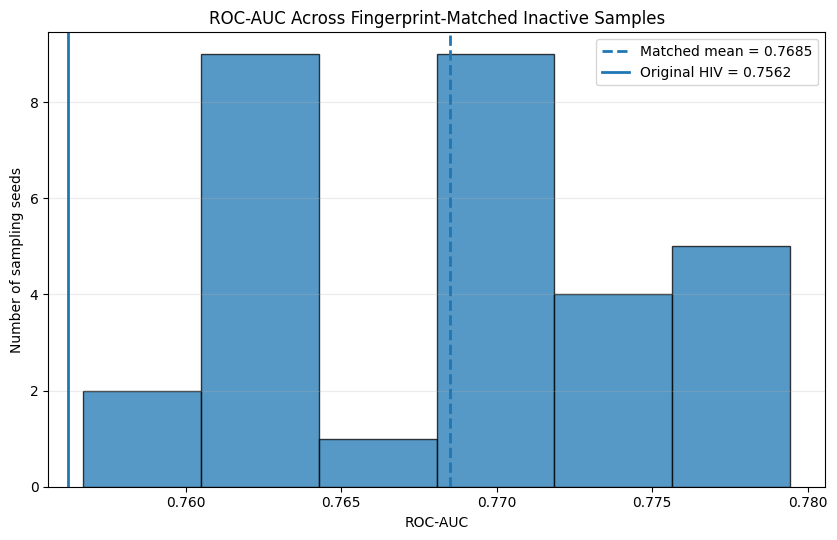

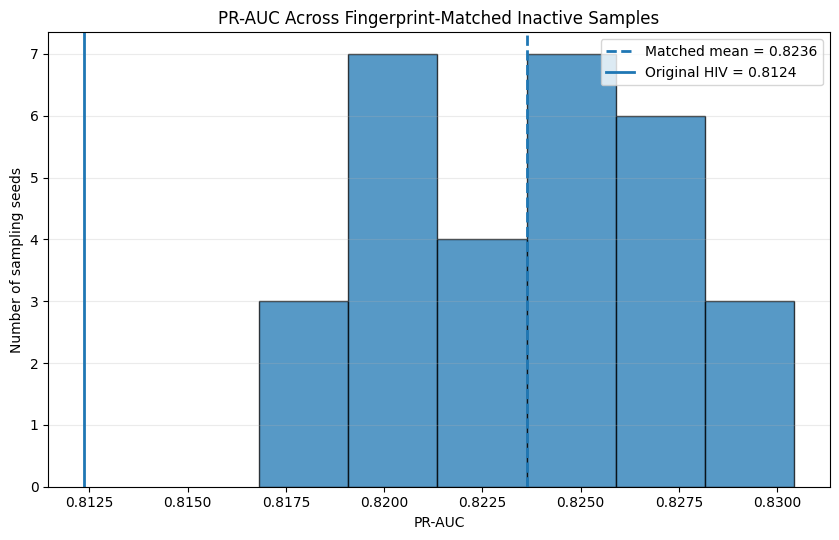

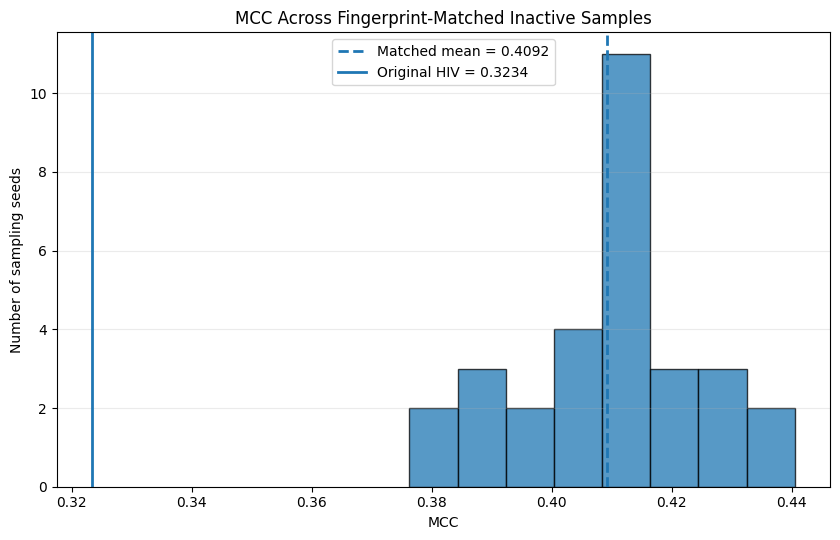

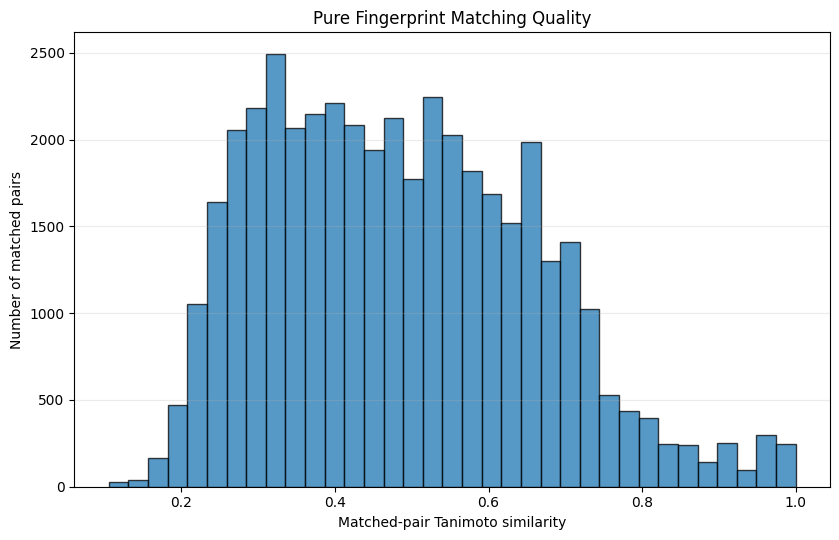

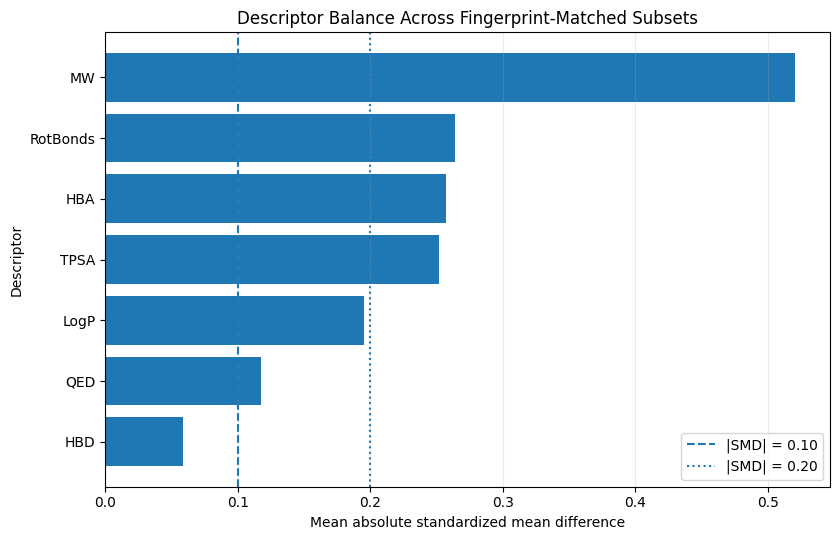

In [18]:

metric_labels = {
    "roc_auc": "ROC-AUC",
    "pr_auc": "PR-AUC",
    "mcc": "MCC",
}

for metric in required_metrics:
    values = sampling_results[metric].to_numpy()
    original_value = float(original_baseline_result.loc[0, metric])

    fig, ax = plt.subplots(figsize=(8.5, 5.5))
    ax.hist(values, bins="auto", edgecolor="black", alpha=0.75)
    ax.axvline(
        values.mean(), linestyle="--", linewidth=2,
        label=f"Matched mean = {values.mean():.4f}"
    )
    ax.axvline(
        original_value, linestyle="-", linewidth=2,
        label=f"Original HIV = {original_value:.4f}"
    )
    ax.set_xlabel(metric_labels[metric])
    ax.set_ylabel("Number of sampling seeds")
    ax.set_title(
        f"{metric_labels[metric]} Across Fingerprint-Matched Inactive Samples"
    )
    ax.legend()
    ax.grid(axis="y", alpha=0.25)
    fig.tight_layout()
    fig.savefig(
        OUTPUT_DIR / f"{metric}_fingerprint_matched_distribution_v4.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()


fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.hist(
    matched_records["tanimoto_similarity"],
    bins=35,
    edgecolor="black",
    alpha=0.75,
)
ax.set_xlabel("Matched-pair Tanimoto similarity")
ax.set_ylabel("Number of matched pairs")
ax.set_title("Pure Fingerprint Matching Quality")
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
fig.savefig(
    OUTPUT_DIR / "matched_pair_tanimoto_distribution_v4.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


plot_df = descriptor_balance_summary.sort_values(
    "mean_absolute_smd", ascending=True
)

fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.barh(
    plot_df["descriptor"],
    plot_df["mean_absolute_smd"],
)
ax.axvline(0.10, linestyle="--", linewidth=1.5, label="|SMD| = 0.10")
ax.axvline(0.20, linestyle=":", linewidth=1.5, label="|SMD| = 0.20")
ax.set_xlabel("Mean absolute standardized mean difference")
ax.set_ylabel("Descriptor")
ax.set_title("Descriptor Balance Across Fingerprint-Matched Subsets")
ax.legend()
ax.grid(axis="x", alpha=0.25)
fig.tight_layout()
fig.savefig(
    OUTPUT_DIR / "descriptor_smd_balance_v4.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


## 17. Otomatik Results, Discussion ve Reviewer Response taslakları

In [19]:

def metric_summary(metric):
    return uncertainty_summary[
        uncertainty_summary["metric"] == metric.upper()
    ].iloc[0]


def metric_comparison(metric):
    return original_vs_matched[
        original_vs_matched["metric"] == metric.upper()
    ].iloc[0]


roc_s = metric_summary("roc_auc")
pr_s = metric_summary("pr_auc")
mcc_s = metric_summary("mcc")

roc_c = metric_comparison("roc_auc")
pr_c = metric_comparison("pr_auc")
mcc_c = metric_comparison("mcc")

mean_tanimoto = tanimoto_quality_summary.loc[
    0, "overall_mean_tanimoto"
]
median_tanimoto = tanimoto_quality_summary.loc[
    0, "overall_median_tanimoto"
]
mean_same_scaffold = tanimoto_quality_summary.loc[
    0, "mean_same_scaffold_rate"
]
mean_scaffold_jaccard = tanimoto_quality_summary.loc[
    0, "mean_scaffold_jaccard"
]

results_text = f"""
To evaluate sensitivity to inactive-compound selection using a direct
structure-based matching strategy, 30 alternative inactive training subsets
were constructed by pure radius-2 Morgan-fingerprint Tanimoto matching. Each
subset contained 1,412 unique inactive compounds. The active training
compounds, fixed held-out test set, molecular representation, Random Forest
hyperparameters, model random state, and classification threshold were held
constant; only inactive-compound composition varied.

Across the 30 fingerprint-matched subsets, ROC-AUC was
{roc_s['mean']:.4f} ± {roc_s['sd']:.4f}
(bootstrap 95% CI: {roc_s['bootstrap_ci95_low']:.4f}–
{roc_s['bootstrap_ci95_high']:.4f}; range:
{roc_s['minimum']:.4f}–{roc_s['maximum']:.4f}).
PR-AUC was {pr_s['mean']:.4f} ± {pr_s['sd']:.4f}, and MCC was
{mcc_s['mean']:.4f} ± {mcc_s['sd']:.4f}. Under the same controlled protocol,
the archived HIV7 inactive subset yielded ROC-AUC
{roc_c['original_baseline']:.4f}, PR-AUC
{pr_c['original_baseline']:.4f}, and MCC
{mcc_c['original_baseline']:.4f}.

The mean matched-pair Tanimoto similarity was {mean_tanimoto:.3f}
(median={median_tanimoto:.3f}). The mean same-scaffold matching rate was
{mean_same_scaffold:.3f}, and the mean scaffold Jaccard overlap was
{mean_scaffold_jaccard:.3f}. These findings quantify the degree to which
performance depends on inactive-class composition under a chemically
constrained alternative-sampling design.
"""

discussion_text = f"""
The inactive-sampling analysis should not be interpreted as identifying a
universally superior negative subset. Instead, it evaluates whether the main
model behaviour is preserved when the inactive class is replaced by
structure-matched alternatives. The relatively narrow seed-to-seed
distributions quantify sampling uncertainty under controlled conditions.
Any residual difference from the archived HIV7 subset indicates that
inactive-class composition contributes to model performance and should
therefore be documented explicitly. Importantly, the analysis avoids changing
the active compounds, test set, representation, classifier settings, or
decision threshold.
"""

reviewer_response = f"""
Response: We thank the reviewer for requesting clarification and a sensitivity
analysis of the inactive-compound selection. We corrected the dataset
description to reflect the GitHub HIV7.csv file used in all model
implementations: 2,885 compounds, including 1,473 active and 1,412 inactive
compounds. We also removed the unsupported statement that the selected subset
was intrinsically more reliable.

We conducted a new controlled sensitivity analysis using 30 alternative
inactive training subsets. To ensure direct chemical comparability, each
alternative subset was generated by pure radius-2 Morgan-fingerprint Tanimoto
matching against the archived HIV7 inactive compounds, with same-scaffold
candidates preferred when available. Each repetition contained 1,412 unique
inactive compounds. The active training compounds, held-out test set,
fingerprint representation, Random Forest hyperparameters, model random state,
and classification threshold were fixed; only the composition of the inactive
training class was changed.

The matched subsets yielded ROC-AUC
{roc_s['mean']:.4f} ± {roc_s['sd']:.4f}, PR-AUC
{pr_s['mean']:.4f} ± {pr_s['sd']:.4f}, and MCC
{mcc_s['mean']:.4f} ± {mcc_s['sd']:.4f}. The archived HIV7 subset yielded
ROC-AUC {roc_c['original_baseline']:.4f}, PR-AUC
{pr_c['original_baseline']:.4f}, and MCC
{mcc_c['original_baseline']:.4f} under the identical protocol. The mean
matched-pair Tanimoto similarity was {mean_tanimoto:.3f}. Seed-level results,
bootstrap confidence intervals, scaffold-overlap statistics, descriptor
balance, excluded invalid-SMILES records, and complete reproducibility details
have been added to the Supplementary Information. We now explicitly state that
inactive-class composition is a source of sampling variability and avoid
claiming that balancing alone establishes improved robustness.
"""

print("RESULTS DRAFT\n", results_text)
print("\nDISCUSSION DRAFT\n", discussion_text)
print("\nREVIEWER RESPONSE DRAFT\n", reviewer_response)

with open(
    OUTPUT_DIR / "automatic_results_interpretation_v4.txt",
    "w", encoding="utf-8"
) as f:
    f.write(results_text.strip() + "\n")

with open(
    OUTPUT_DIR / "automatic_discussion_interpretation_v4.txt",
    "w", encoding="utf-8"
) as f:
    f.write(discussion_text.strip() + "\n")

with open(
    OUTPUT_DIR / "reviewer1_response_draft_v4.txt",
    "w", encoding="utf-8"
) as f:
    f.write(reviewer_response.strip() + "\n")


RESULTS DRAFT
 
To evaluate sensitivity to inactive-compound selection using a direct
structure-based matching strategy, 30 alternative inactive training subsets
were constructed by pure radius-2 Morgan-fingerprint Tanimoto matching. Each
subset contained 1,412 unique inactive compounds. The active training
compounds, fixed held-out test set, molecular representation, Random Forest
hyperparameters, model random state, and classification threshold were held
constant; only inactive-compound composition varied.

Across the 30 fingerprint-matched subsets, ROC-AUC was
0.7685 ± 0.0060
(bootstrap 95% CI: 0.7664–
0.7706; range:
0.7567–0.7794).
PR-AUC was 0.8236 ± 0.0038, and MCC was
0.4092 ± 0.0157. Under the same controlled protocol,
the archived HIV7 inactive subset yielded ROC-AUC
0.7562, PR-AUC
0.8124, and MCC
0.3234.

The mean matched-pair Tanimoto similarity was 0.486
(median=0.472). The mean same-scaffold matching rate was
0.631, and the mean scaffold Jaccard overlap was
0.310. These fi

## 18. Deney manifestosu ve ZIP çıktısı

In [19]:

experiment_manifest = {
    "analysis": "Reviewer 1 pure fingerprint inactive sampling sensitivity V4",
    "original_subset_url": ORIGINAL_SUBSET_URL,
    "full_dataset_source": full_source,
    "original_counts": {
        "active": EXPECTED_ORIGINAL_ACTIVE,
        "inactive": EXPECTED_ORIGINAL_INACTIVE,
        "total": EXPECTED_ORIGINAL_TOTAL,
    },
    "excluded_invalid_full_dataset_smiles": int(len(invalid_full)),
    "n_repetitions": N_REPETITIONS,
    "sampling_seeds": SAMPLING_SEEDS,
    "n_inactive_per_subset": N_INACTIVE_PER_TRAINING_SET,
    "matching": {
        "method": "pure Morgan fingerprint Tanimoto",
        "top_k_neighbors_stored": TOP_K_NEIGHBORS,
        "top_selection_window": TOP_SELECTION_WINDOW,
        "similarity_temperature": SIMILARITY_TEMPERATURE,
        "prefer_same_scaffold": PREFER_SAME_SCAFFOLD,
    },
    "fingerprint": {
        "type": "Morgan bit vector",
        "radius": RADIUS,
        "n_bits": N_BITS,
    },
    "random_forest_parameters": RF_PARAMS,
    "decision_threshold": DECISION_THRESHOLD,
}

with open(
    OUTPUT_DIR / "experiment_manifest_v4.json",
    "w", encoding="utf-8"
) as f:
    json.dump(experiment_manifest, f, indent=2, ensure_ascii=False)

zip_path = shutil.make_archive(
    "reviewer1_inactive_sampling_v4_pure_fingerprint_outputs",
    "zip",
    root_dir=OUTPUT_DIR,
)

print("ZIP oluşturuldu:", zip_path)
print("\nÜretilen dosyalar:")
for path in sorted(OUTPUT_DIR.iterdir()):
    print("-", path.name)

try:
    from google.colab import files
    files.download(zip_path)
except Exception:
    print("Otomatik indirme yalnızca Google Colab ortamında çalışır.")


ZIP oluşturuldu: /content/reviewer1_inactive_sampling_v4_pure_fingerprint_outputs.zip

Üretilen dosyalar:
- automatic_discussion_interpretation_v4.txt
- automatic_results_interpretation_v4.txt
- descriptor_balance_all_seeds_v4.csv
- descriptor_balance_summary_v4.csv
- descriptor_smd_balance_v4.png
- excluded_invalid_smiles_full_MoleculeNet_v4.csv
- experiment_manifest_v4.json
- fingerprint_sampling_uncertainty_summary_v4.csv
- fixed_active_training_set_v4.csv
- fixed_held_out_test_set_v4.csv
- fixed_test_predictions_all_seeds_v4.csv
- manuscript_ready_matching_quality_table_v4.csv
- manuscript_ready_performance_table_v4.csv
- matched_inactive_records_all_seeds_v4.csv
- matched_pair_tanimoto_distribution_v4.png
- mcc_fingerprint_matched_distribution_v4.png
- original_1412_inactive_baseline_metrics_v4.csv
- original_HIV7_expected_vs_observed_v4.csv
- original_inactive_chemical_features_v4.csv
- original_vs_fingerprint_matched_distribution_v4.csv
- pr_auc_fingerprint_matched_distribution_

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


# Çalıştırma sonrası

Colab sonunda indirilen:

`reviewer1_inactive_sampling_v4_pure_fingerprint_outputs.zip`

dosyasını buraya yükleyin. Version 2, Version 3 ve Version 4 sonuçları birlikte
karşılaştırılarak:

- ana metinde kullanılacak analiz,
- Supplementary Information tabloları,
- hakeme verilecek yanıt,
- Results ve Discussion metinleri

nihai ve şeffaf biçimde hazırlanacaktır.

> Not: Tüm havuz için Tanimoto en-yakın-komşu hesabı Version 3'e göre daha uzun
> sürebilir. Colab oturumunu açık tutun ve hücreyi tamamlanana kadar durdurmayın.
